# Model Decision Tree

## 3.4. Drzewa decyzyjne (Decision Tree)

Drzewa decyzyjne należą do grupy modeli uczenia nadzorowanego, które podejmują decyzje poprzez
rekurencyjne dzielenie przestrzeni cech na coraz mniejsze podzbiory.  
Model przyjmuje postać struktury drzewa, gdzie:

- **węzły wewnętrzne (ang. internal nodes)** reprezentują test na jednej ze zmiennych,
  np. *Prob_H_b365 > 0.45?*
- **gałęzie (ang. branches)** odpowiadają wynikom testu,
- **liście (ang. leaves)** zawierają finalną predykcję modelu (np. jedną z klas: *H*, *D*, *A*).

### 3.4.1. Algorytm budowania drzewa

Budowa drzewa polega na iteracyjnym wyszukiwaniu takiego podziału danych (cecha + próg),
który **maksymalizuje czystość klas** w powstałych gałęziach.  
Najpopularniejsze funkcje oceny czystości to:

#### • Indeks Giniego

\[
Gini = 1 - \sum_{k=1}^{K} p_k^2
\]

gdzie \(p_k\) jest udziałem klasy \(k\) w danym węźle.

#### • Entropia

\[
Entropy = - \sum_{k=1}^{K} p_k \log_2 (p_k)
\]

Im niższa wartość miary, tym bardziej jednorodny węzeł (czyli lepszy podział).

### 3.4.2. Zalety drzew decyzyjnych

Drzewa decyzyjne są chętnie stosowane ze względu na:

- **brak wymogu skalowania cech**,  
- **obsługę nieliniowości** oraz interakcji pomiędzy zmiennymi,
- **intuicyjną interpretowalność** (możliwość wizualizacji struktury drzewa),
- możliwość ustalania wag klas (`class_weight='balanced'`) przy danych niezrównoważonych.

Cechy te czynią drzewa atrakcyjnym modelem bazowym przy klasyfikacji wyników sportowych,
gdzie zależności między zmiennymi mogą być bardzo nieliniowe.

### 3.4.3. Wady drzew decyzyjnych

Główną słabością drzew decyzyjnych jest **wysoka podatność na przeuczenie** (overfitting).  
Drzewo niekontrolowane (bez limitu głębokości) może praktycznie „zapamiętać” dane uczące.

Dlatego konieczne jest zastosowanie tzw. *przycinania* drzewa poprzez dobranie hiperparametrów takich jak:

- `max_depth` – maksymalna głębokość drzewa,  
- `min_samples_split` – minimalna liczba próbek do podziału węzła,  
- `min_samples_leaf` – minimalna liczba próbek w liściu,  
- `class_weight` – regulacja wpływu częstości klas.

Dobór tych parametrów odbywa się zwykle metodą wyszukiwania siatką (GridSearchCV).

### 3.4.4. Zastosowanie w analizie wyników meczów

W niniejszej pracy drzewo decyzyjne wykorzystane zostało jako model klasyfikacyjny
przewidujący rezultat meczu piłkarskiego spośród trzech klas:

- **H** – zwycięstwo gospodarzy,
- **D** – remis,
- **A** – zwycięstwo gości.

Model trenowany jest na tych samych cechach, które wykorzystano przy regresji logistycznej,
co umożliwia uczciwe porównanie jakości obu podejść — modeli liniowych i nieliniowych.
Drzewo potrafi uchwycić złożone interakcje między cechami (np. między kursami bukmacherskimi,
formą z ostatnich meczów czy różnicą jakości drużyn), co czyni je dobrym uzupełnieniem
bardziej klasycznych metod statystycznych.



Przygotowanie danych

In [1]:
# --- podstawy ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

LEAGUE = "premier_league"
# LEAGUE = "serie_a"
# LEAGUE = "la_liga"
# LEAGUE = "bundesliga"
# LEAGUE = "ligue_1"
# LEAGUE = "all_leagues"

EXPERIMENT = "tree_models"

DATA_DIR = Path("../data/processed")

DATA_PATH = DATA_DIR / LEAGUE / f"{LEAGUE}_features.csv"

RESULTS_DIR = Path(f"../results/{LEAGUE}/{EXPERIMENT}")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("LEAGUE:", LEAGUE)
print("DATA_PATH:", DATA_PATH)
print("RESULTS_DIR:", RESULTS_DIR)

LEAGUE: premier_league
DATA_PATH: ..\data\processed\premier_league\premier_league_features.csv
RESULTS_DIR: ..\results\premier_league\tree_models


In [2]:
def save_plot(filename, dpi=150):
    plt.savefig(
        RESULTS_DIR / filename,
        dpi=dpi,
        bbox_inches="tight"
    )

def save_df(df, filename):
    df.to_csv(
        RESULTS_DIR / filename,
        index=False
    )

def close_plot():
    plt.close()



def plot_and_save_class_distribution(
    y_true_cls,
    y_pred_cls,
    option_suffix,      # np. "A", "B", "BIN"
    filename_prefix     # np. "class_distribution"
):
    """
    y_true_cls : lista klas ["H","D","A"] lub ["0","1"] itp.
    y_pred_cls : lista klas
    """

    # --- liczniki ---
    df_counts = (
        pd.DataFrame({
            "True": y_true_cls,
            "Pred": y_pred_cls
        })
        .melt(var_name="Type", value_name="Class")
        .value_counts()
        .reset_index(name="Count")
    )

    # rozbijamy na true / pred
    df_true = df_counts[df_counts["Type"] == "True"][["Class","Count"]] \
        .rename(columns={"Count":"True_Count"})
    df_pred = df_counts[df_counts["Type"] == "Pred"][["Class","Count"]] \
        .rename(columns={"Count":"Pred_Count"})

    df_final = (
        pd.merge(df_true, df_pred, on="Class", how="outer")
        .fillna(0)
        .sort_values("Class")
    )

    # --- zapis CSV ---
    save_df(
        df_final,
        f"{filename_prefix}_{option_suffix}.csv"
    )

    # --- wykres ---
    x = np.arange(len(df_final))
    width = 0.35

    plt.figure(figsize=(8,5))
    plt.bar(x - width/2, df_final["True_Count"], width, label="True")
    plt.bar(x + width/2, df_final["Pred_Count"], width, label="Pred")

    plt.xticks(x, df_final["Class"])
    plt.ylabel("Liczba meczów")
    plt.title(f"Rozkład klas — Opcja {option_suffix}")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)

    save_plot(f"{filename_prefix}_{option_suffix}.png")
    plt.show()
    close_plot()

    return df_final

In [3]:
df = pd.read_csv(DATA_PATH, parse_dates=["Date"])
df = df.sort_values(["Date", "HomeTeam", "AwayTeam"]).reset_index(drop=True)
print(df.shape)
df.head(3)

(3420, 113)


,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,...,FormDiff_AttDefRatio_last5,FormDiff_GoalsShare_last5,Home_RecentFormIdx,Away_RecentFormIdx,FormDiff_RecentFormIdx,Market_ImpliedDiff_b365,Market_ImpliedDiff_ps,Market_BigHomeFav,Market_BigAwayFav,Market_BalancedMatch
0,E0,2014-08-16,Arsenal,Crystal Palace,2.0,1.0,H,14.0,4.0,6.0,...,NaN,NaN,NaN,NaN,NaN,0.718593,0.708064,1,0,0
1,E0,2014-08-16,Leicester,Everton,2.0,2.0,D,11.0,13.0,3.0,...,NaN,NaN,NaN,NaN,NaN,-0.101796,-0.086236,0,0,0
2,E0,2014-08-16,Manchester United,Swansea,1.0,2.0,A,14.0,5.0,5.0,...,NaN,NaN,NaN,NaN,NaN,0.627931,0.622914,1,0,0


In [3]:
# cols_to_exclude = {
#     # meta / identyfikatory
#     "Div", "Date", "Season", "SourceFile", "HomeTeam", "AwayTeam", "Referee",

#     # wynikowe i bieżące statystyki meczu (niedostępne przed meczem)
#     "FTHG", "FTAG", "HTHG", "HTAG", "FTR",
#     "GoalDiff", "TotalGoals",
#     "HS", "AS", "HST", "AST", "HF", "AF", "HC", "AC",
#     "HY", "AY", "HR", "AR",

#     # NOWE — usuwamy nadmiarowe prawdopodobieństwa, które psują regresję
#     "Prob_D_b365", "Prob_A_b365"
# }

In [4]:
target = "FTR"
cols_to_exclude = {
    # meta / identyfikatory
    "Div", "Date", "Season", "SourceFile", "HomeTeam", "AwayTeam", "Referee",

    # wynik meczu – niedostępne przed spotkaniem
    "FTHG", "FTAG", "HTHG", "HTAG", "FTR",
    "GoalDiff", "TotalGoals",
    "HS", "AS", "HST", "AST", "HF", "AF", "HC", "AC",
    "HY", "AY", "HR", "AR",

    # bukmacher – nadmiarowe prawdopodobieństwa i miary
    "Prob_D_b365", "Prob_A_b365",
    "Prob_H_ps", "Prob_D_ps", "Prob_A_ps",
    "Margin_B365", "Margin_PS",
    "OddsDiff_B365", "OddsDiff_PS",
    "OddsSpread_H", "OddsSpread_D", "OddsSpread_A",

    # forma gospodarzy – duplikaty lub mało stabilne
    "Home_Wins_last5",
    "Home_CleanSheets_last5",
    "Home_Conceded0plus_last5",
    "Home_GD_last3",
    "Home_Pts_last3",
    "Home_GD_last10",         # silna korelacja z Pts_last10
    "Home_AvgGD_season",

    # forma gości – duplikaty lub mało stabilne
    "Away_Wins_last5",
    "Away_CleanSheets_last5",
    "Away_Conceded0plus_last5",
    "Away_GD_last3",
    "Away_Pts_last3",
    "Away_GD_last10",         # silna korelacja z Pts_last10
    "Away_AvgGD_season",

    # FormDiff – różnice formy (duplikaty)
    "FormDiff_Wins_last5",
    "FormDiff_CleanSheets_last5",
    "FormDiff_Conceded0plus_last5",
    "FormDiff_GD_last3",
    "FormDiff_Pts_last3",
    "FormDiff_GD_last10",
    "FormDiff_Pts_last10",

    # kalendarz – duplikat Weekday
    "IsWeekend",

    # siła sezonu – duplikat PtsDiff
    "SeasonStrength_GDDiff",
}

# kandydaci na cechy:
candidate_cols = [c for c in df.columns if c not in cols_to_exclude]

# wzorce cech predykcyjnych (rynek, forma, sezon, czas)
keep_patterns = (
    "Prob_", "Margin_", "OddsDiff", "OddsSpread",
    "Home_", "Away_", "FormDiff_", "Pts_trend_3v10",
    "SeasonStrength_", "Month", "Weekday", "IsWeekend"#, "Market_"
)

X_features = [c for c in candidate_cols if any(p in c for p in keep_patterns)]

# sanity check
print(f"Liczba wybranych cech: {len(X_features)}")

Liczba wybranych cech: 32


In [5]:
from sklearn.preprocessing import LabelEncoder


# Label encoding: A/D/H -> 0/1/2 (kolejność zależy od LabelEncoder)
le_dt = LabelEncoder()
y_clf_dt = le_dt.fit_transform(df[target])

# Cecha X – te same X_features co w innych modelach
X_clf_dt = df[X_features].copy()

# Podział czasowy jak wcześniej

split_date = pd.Timestamp("2022-07-01")
train_mask = df["Date"] < split_date
test_mask  = df["Date"] >= split_date

X_train_dt = X_clf_dt.loc[train_mask].reset_index(drop=True)
X_test_dt  = X_clf_dt.loc[test_mask].reset_index(drop=True)
y_train_dt = y_clf_dt[train_mask]
y_test_dt  = y_clf_dt[test_mask]

X_train_dt.shape, X_test_dt.shape, len(y_train_dt), len(y_test_dt)

((2660, 32), (760, 32), 2660, 760)

Model bazowy drzewa + pipeline

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


dt_base = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=0
)
pipe_dt = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", dt_base)
])

GridSearchCV – strojenie hiperparametrów

In [7]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    "model__max_depth": [4, 6, 8, 10, 12, 15, 20, None],
    "model__min_samples_split": [2, 5, 10, 20, 50, 100],
    "model__min_samples_leaf": [1, 2, 5, 10, 20, 50],
    "model__max_features": ["sqrt", "log2", None],
    "model__criterion": ["gini", "entropy"]
}
grid_dt = GridSearchCV(
    estimator=pipe_dt,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

print("Trenowanie GridSearchCV (DecisionTree)...")
grid_dt.fit(X_train_dt, y_train_dt)

print("Najlepsze parametry:", grid_dt.best_params_)
print("Najlepszy wynik CV (Macro-F1):", grid_dt.best_score_)

Trenowanie GridSearchCV (DecisionTree)...
Fitting 5 folds for each of 1728 candidates, totalling 8640 fits
Najlepsze parametry: {'model__criterion': 'entropy', 'model__max_depth': 4, 'model__max_features': None, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}
Najlepszy wynik CV (Macro-F1): 0.4817965333162473


Ewaluacja na zbiorze testowym


=== Decision Tree (multiclass H/D/A) — TEST ===
Accuracy:  0.5184
Macro-F1:  0.4958

=== Classification report (Decision Tree) ===
              precision    recall  f1-score   support

           A       0.54      0.55      0.54       232
           D       0.27      0.38      0.32       169
           H       0.71      0.56      0.63       359

    accuracy                           0.52       760
   macro avg       0.51      0.50      0.50       760
weighted avg       0.56      0.52      0.53       760



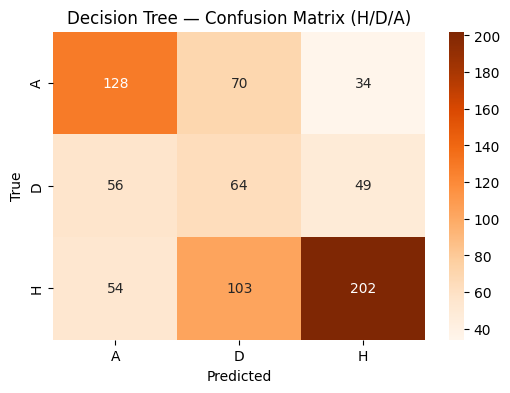

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.calibration import CalibratedClassifierCV
best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test_dt)

acc_dt = accuracy_score(y_test_dt, y_pred_dt)
f1_dt  = f1_score(y_test_dt, y_pred_dt, average="macro")


calibrated_dt = CalibratedClassifierCV(
    best_dt,
    method="isotonic",   # albo "sigmoid"
    cv=5
)

calibrated_dt.fit(X_train_dt, y_train_dt)



print("\n=== Decision Tree (multiclass H/D/A) — TEST ===")
print(f"Accuracy:  {acc_dt:.4f}")
print(f"Macro-F1:  {f1_dt:.4f}")

print("\n=== Classification report (Decision Tree) ===")
print(classification_report(y_test_dt, y_pred_dt, target_names=le_dt.classes_))

# Macierz pomyłek
cm_dt = confusion_matrix(y_test_dt, y_pred_dt)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt=".0f",
    cmap="Oranges",
    xticklabels=le_dt.classes_,
    yticklabels=le_dt.classes_
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Decision Tree — Confusion Matrix (H/D/A)")
save_plot("decision_tree_confusion_matrix.png")
plt.show()
close_plot()

### Kalibracja modelu Decision Tree

Model drzewa decyzyjnego został najpierw wytrenowany i dobrany pod kątem **jakości klasyfikacji (Macro-F1)** przy użyciu `GridSearchCV`.  
Następnie najlepszy model (`best_dt`) został **skalibrowany metodą isotonic**, aby poprawić jakość **przewidywanych prawdopodobieństw**, bez zmiany samych predykcji klas.

Metryki takie jak **Accuracy, Macro-F1 oraz macierz pomyłek** raportowane są dla modelu bazowego (nieskalibrowanego), natomiast **analizy probabilistyczne** (krzywe kalibracyjne) wykonywane są na modelu skalibrowanym.  
Takie rozdzielenie jest poprawne i zgodne z dobrą praktyką w uczeniu maszynowym.


In [9]:
####################
# ZAPIS WYNIKÓW
######################

results_dt = pd.DataFrame([{
    "Model": "Decision Tree (Multiclass)",
    "Accuracy": acc_dt,
    "Macro-F1": f1_dt,
    "League": LEAGUE,
    "SplitDate": split_date,
    "N_train": len(y_train_dt),
    "N_test": len(y_test_dt)
}])

save_df(results_dt, "decision_tree_results.csv")
display(results_dt)


,Model,Accuracy,Macro-F1,League,SplitDate,N_train,N_test
0,Decision Tree (Multiclass),0.518421,0.49576,premier_league,2022-07-01,2660,760


In [10]:
report_dt = classification_report(
    y_test_dt,
    y_pred_dt,
    target_names=le_dt.classes_,
    output_dict=True
)

df_report_dt = pd.DataFrame(report_dt).T
df_report_dt["Model"] = "Decision Tree (Multiclass)"
df_report_dt["League"] = LEAGUE

save_df(df_report_dt, "decision_tree_classification_report.csv")
display(df_report_dt)

,precision,recall,f1-score,support,Model,League
A,0.537815,0.551724,0.544681,232.000000,Decision Tree (Multiclass),premier_league
D,0.270042,0.378698,0.315271,169.000000,Decision Tree (Multiclass),premier_league
H,0.708772,0.562674,0.627329,359.000000,Decision Tree (Multiclass),premier_league
accuracy,0.518421,0.518421,0.518421,0.518421,Decision Tree (Multiclass),premier_league
macro avg,0.505543,0.497699,0.495760,760.000000,Decision Tree (Multiclass),premier_league
weighted avg,0.559025,0.518421,0.532708,760.000000,Decision Tree (Multiclass),premier_league


Wykres ważności cech (feature importance)

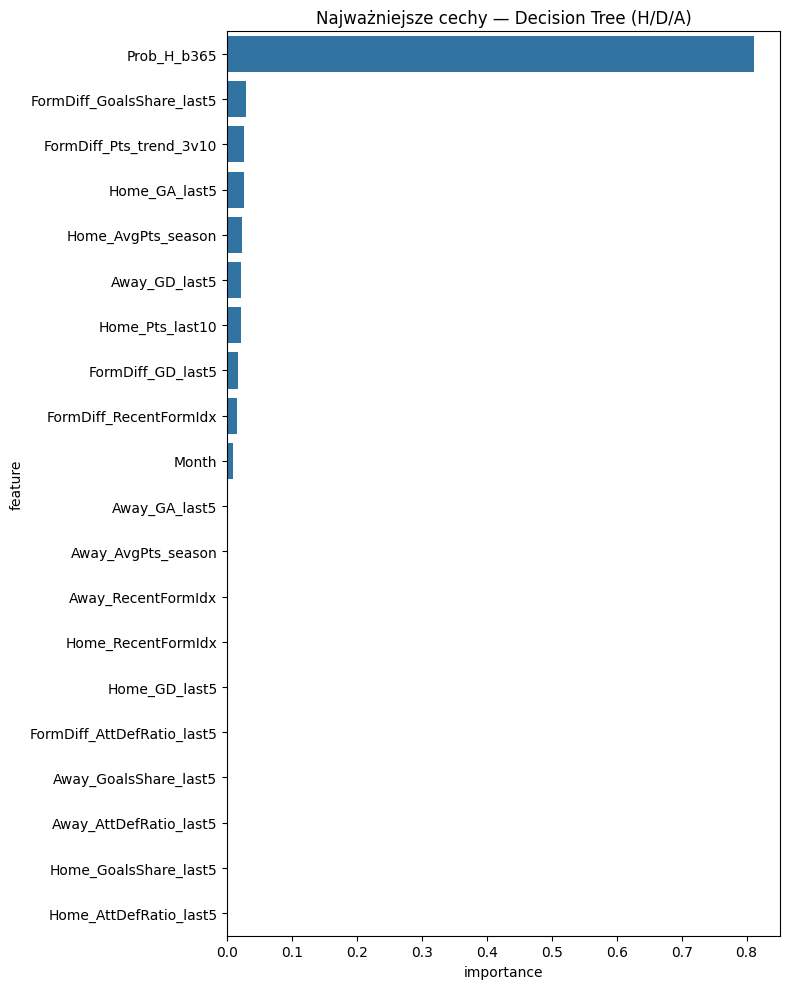

In [11]:
# Pobranie ważności cech z modelu w pipeline
dt_model = best_dt.named_steps["model"]
importances = dt_model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": X_train_dt.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

feat_imp["Model"] = "Decision Tree"
feat_imp["League"] = LEAGUE


# Top 20 cech
top_n = 20
feat_imp_top = feat_imp.head(top_n)

plt.figure(figsize=(8, 0.4*top_n + 2))
sns.barplot(data=feat_imp_top, x="importance", y="feature")
plt.title("Najważniejsze cechy — Decision Tree (H/D/A)")
plt.tight_layout()
save_df(feat_imp, "decision_tree_feature_importance.csv")
save_plot("decision_tree_feature_importance.png")
plt.show()
close_plot()

Learning curve (czy drzewo się przeucza?)

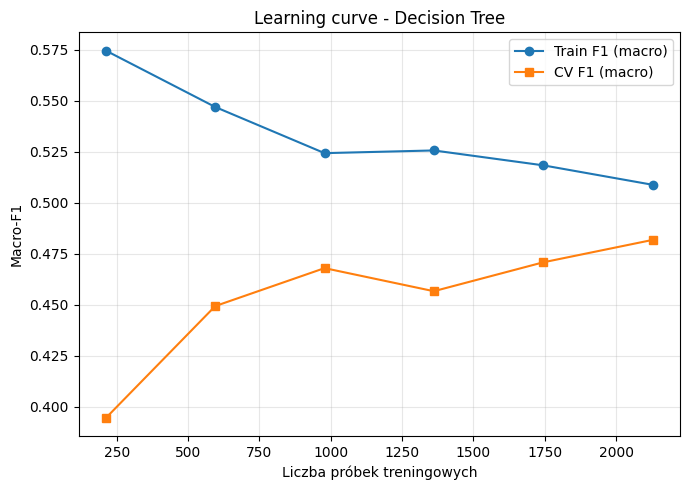

,TrainSize,Train_F1_macro,CV_F1_macro
0,212,0.574505,0.394596
1,595,0.546909,0.449373
2,978,0.524305,0.467968
3,1361,0.525627,0.456656
4,1744,0.518344,0.470794
5,2128,0.508795,0.481797


In [26]:
from sklearn.model_selection import learning_curve


train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_dt,
    X=X_train_dt,
    y=y_train_dt,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 6),
    shuffle=True,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, marker="o", label="Train F1 (macro)")
plt.plot(train_sizes, val_mean, marker="s", label="CV F1 (macro)")
plt.xlabel("Liczba próbek treningowych")
plt.ylabel("Macro-F1")
plt.title("Learning curve - Decision Tree")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
save_plot("decision_tree_learning_curve.png")
plt.show()
close_plot()


lc_df = pd.DataFrame({
    "TrainSize": train_sizes,
    "Train_F1_macro": train_mean,
    "CV_F1_macro": val_mean
})

display(lc_df)

save_df(lc_df, "decision_tree_learning_curve_values.csv")


Wizualizacja drzewa (pierwsze kilka poziomów)

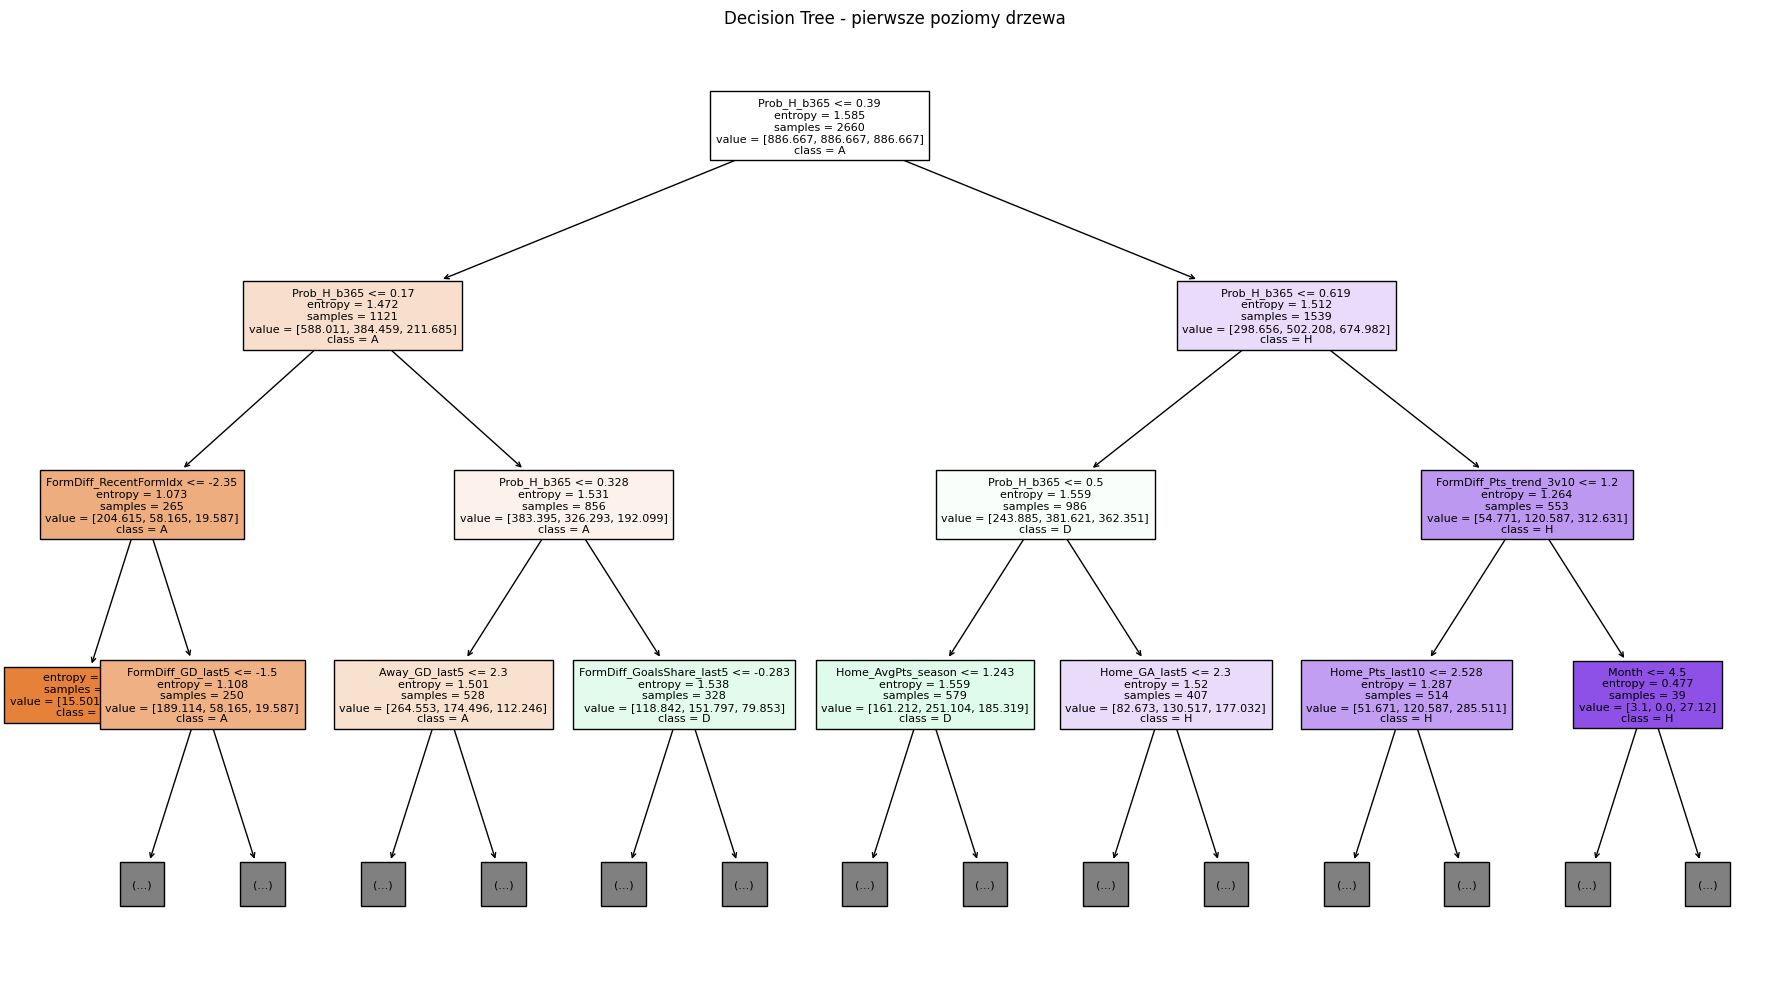

In [13]:
from sklearn.tree import plot_tree


plt.figure(figsize=(18,10))
plot_tree(
    dt_model,
    feature_names=X_train_dt.columns,
    class_names=le_dt.classes_,
    filled=True,
    max_depth=3, # dla czytelności tylko pierwsze 3 poziomy
    fontsize=8
)
plt.title("Decision Tree - pierwsze poziomy drzewa")
plt.tight_layout()
save_plot("decision_tree_structure_depth3.png")
plt.show()
close_plot()


Krzywa kalibracji (czy prawdopodobieństwa są sensowne?)

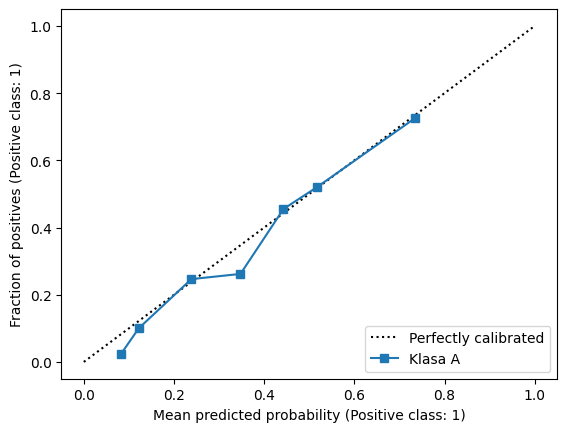

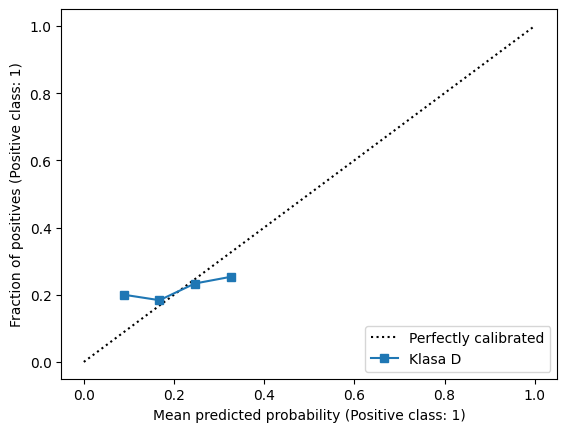

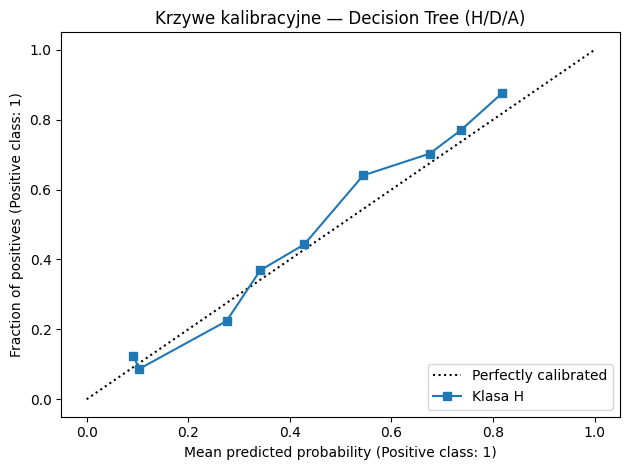

In [28]:
from sklearn.calibration import CalibrationDisplay

calibration_rows = []
#y_proba_dt = best_dt.predict_proba(X_test_dt)
y_proba_dt = calibrated_dt.predict_proba(X_test_dt)
for i, cls in enumerate(le_dt.classes_):
    disp = CalibrationDisplay.from_predictions(
        (y_test_dt == i).astype(int),
        y_proba_dt[:, i],
        n_bins=10,
        name=f"Klasa {cls}"
    )

# zapis punktów do CSV
    for frac_pos, mean_pred in zip(
        disp.prob_true, disp.prob_pred
    ):
        calibration_rows.append({
            "Class": cls,
            "MeanPredictedProb": mean_pred,
            "FractionPositive": frac_pos,
            "Model": "Decision Tree",
            "League": LEAGUE
        })

plt.title("Krzywe kalibracyjne — Decision Tree (H/D/A)")
plt.tight_layout()

save_plot("decision_tree_calibration_curves.png")
plt.show()
close_plot()

# --- zapis CSV ---
df_calibration = pd.DataFrame(calibration_rows)
save_df(df_calibration, "decision_tree_calibration_curves.csv")

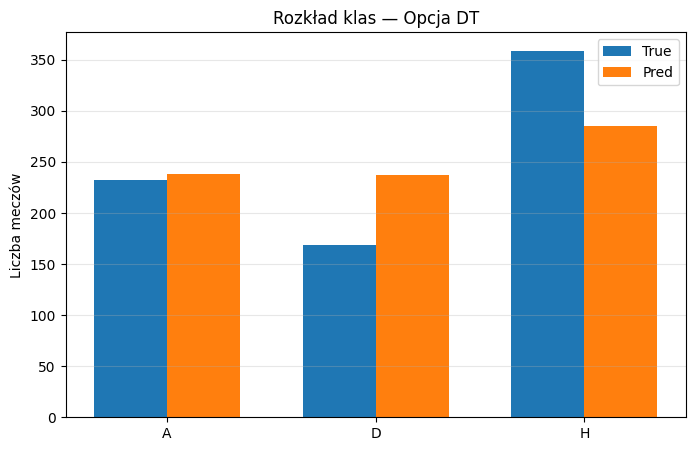

,Class,True_Count,Pred_Count
0,A,232,238
1,D,169,237
2,H,359,285


In [15]:
y_true_cls_dt = le_dt.inverse_transform(y_test_dt)
y_pred_cls_dt = le_dt.inverse_transform(y_pred_dt)

plot_and_save_class_distribution(
    y_true_cls_dt,
    y_pred_cls_dt,
    option_suffix="DT",
    filename_prefix="class_distribution"
)


,Metric,Baseline_HomeWin,Decision_Tree,Gain_vs_Baseline
0,Accuracy,0.472368,0.518421,0.046053
1,Macro-F1,0.213881,0.495760,0.281879


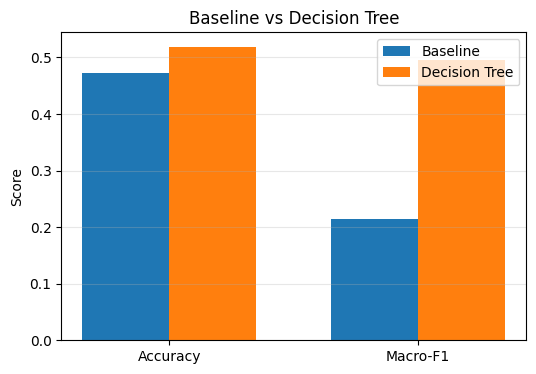

In [16]:
# true klasy
y_true_cls = y_true_cls_dt.tolist()

# --- BASELINE: zawsze Home ---
y_naive = ["H"] * len(y_true_cls)
acc_naive = accuracy_score(y_true_cls, y_naive)
f1_naive  = f1_score(y_true_cls, y_naive, average="macro")

# --- MODEL: Decision Tree ---
acc_model = accuracy_score(y_true_cls, y_pred_cls_dt)
f1_model  = f1_score(y_true_cls, y_pred_cls_dt, average="macro")

df_baseline_compare = pd.DataFrame({
    "Metric": ["Accuracy", "Macro-F1"],
    "Baseline_HomeWin": [acc_naive, f1_naive],
    "Decision_Tree": [acc_model, f1_model],
    "Gain_vs_Baseline": [
        acc_model - acc_naive,
        f1_model - f1_naive
    ]
})

save_df(df_baseline_compare, "baseline_vs_decision_tree.csv")
display(df_baseline_compare)


plt.figure(figsize=(6,4))
x = np.arange(2)
width = 0.35

plt.bar(x - width/2, [acc_naive, f1_naive], width, label="Baseline")
plt.bar(x + width/2, [acc_model, f1_model], width, label="Decision Tree")

plt.xticks(x, ["Accuracy", "Macro-F1"])
plt.ylabel("Score")
plt.title("Baseline vs Decision Tree")
plt.legend()
plt.grid(axis="y", alpha=0.3)

save_plot("baseline_vs_decision_tree.png")
plt.show()
close_plot()


C:\Users\tdroz\AppData\Local\Temp\ipykernel_9532\562128773.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: accuracy_score(x["y_true"], x["y_pred"]))


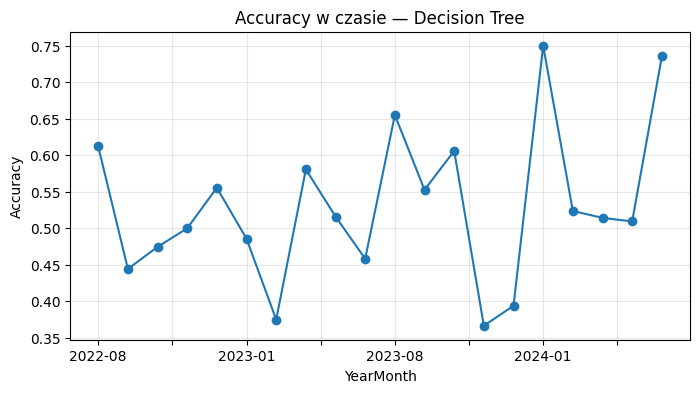

In [17]:
MIN_MATCHES = 10

df_eval_dt = df.loc[test_mask, ["Date"]].copy()
df_eval_dt["y_true"] = y_true_cls_dt
df_eval_dt["y_pred"] = y_pred_cls_dt
df_eval_dt["YearMonth"] = df_eval_dt["Date"].dt.to_period("M").astype(str)

acc_per_month_dt = (
    df_eval_dt
    .groupby("YearMonth")
    .filter(lambda x: len(x) >= MIN_MATCHES)
    .groupby("YearMonth")
    .apply(lambda x: accuracy_score(x["y_true"], x["y_pred"]))
)

plt.figure(figsize=(8,4))
acc_per_month_dt.plot(marker="o")
plt.ylabel("Accuracy")
plt.title("Accuracy w czasie — Decision Tree")
plt.grid(alpha=0.3)

save_plot("accuracy_per_month_decision_tree.png")
plt.show()
close_plot()


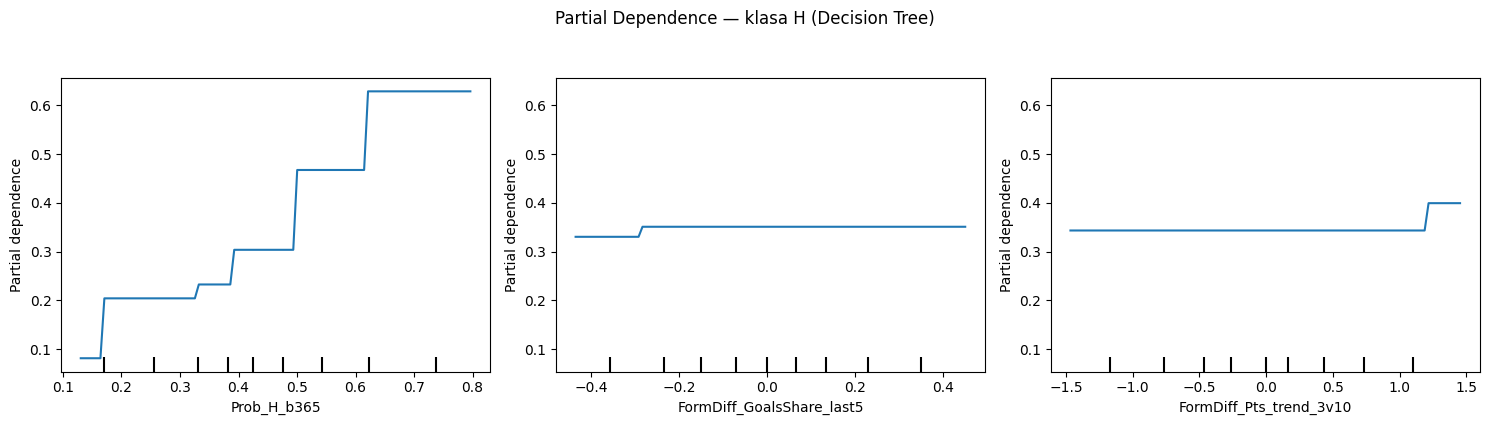

In [23]:
from sklearn.inspection import PartialDependenceDisplay

top_features = feat_imp["feature"].head(3).tolist()
top_features

fig, ax = plt.subplots(1, len(top_features), figsize=(5*len(top_features), 4))

PartialDependenceDisplay.from_estimator(
    best_dt,
    X_train_dt,
    features=top_features,
    target=le_dt.transform(["H"])[0],  # klasa Home Win
    ax=ax
)

plt.suptitle("Partial Dependence — klasa H (Decision Tree)", y=1.05)
plt.tight_layout()

save_plot("pdp_top_features_class_H.png")
plt.show()
close_plot()


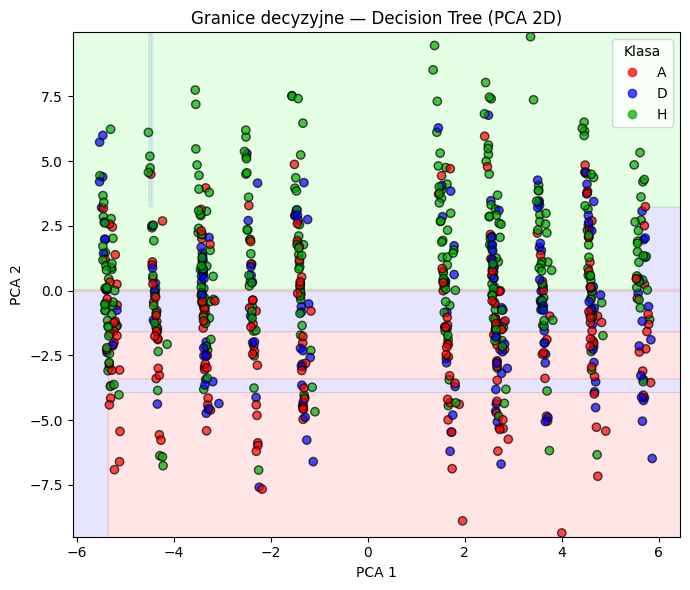

In [25]:
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import ListedColormap


# --- 1. Imputacja ---
imputer = best_dt.named_steps["imputer"]

X_train_imp = imputer.transform(X_train_dt)
X_test_imp  = imputer.transform(X_test_dt)

# --- 2. PCA ---
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_imp)
X_test_pca  = pca.transform(X_test_imp)

# --- 3. Drzewo na PCA ---
dt_pca = DecisionTreeClassifier(
    max_depth=best_dt.named_steps["model"].max_depth,
    min_samples_leaf=best_dt.named_steps["model"].min_samples_leaf,
    min_samples_split=best_dt.named_steps["model"].min_samples_split,
    class_weight="balanced",
    random_state=42
)
dt_pca.fit(X_train_pca, y_train_dt)


# --- 4. Decision surface ---
x_min, x_max = X_train_pca[:, 0].min() - 0.5, X_train_pca[:, 0].max() + 0.5
y_min, y_max = X_train_pca[:, 1].min() - 0.5, X_train_pca[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = dt_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

cmap_light = ListedColormap(["#FFAAAA", "#AAAAFF", "#AAFFAA"])
cmap_bold  = ListedColormap(["#FF0000", "#0000FF", "#00AA00"])

plt.figure(figsize=(7,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)

scatter = plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=y_test_dt,
    cmap=cmap_bold,
    edgecolor="k",
    alpha=0.7
)

handles, labels = scatter.legend_elements()
plt.legend(
    handles,
    le_dt.classes_,
    title="Klasa",
    loc="best"
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Granice decyzyjne — Decision Tree (PCA 2D)")
plt.tight_layout()

save_plot("dt_decision_surface_pca_2d.png")
plt.show()
close_plot()

Wizualizacja granic decyzyjnych w przestrzeni PCA 2D pokazuje charakterystyczne, osiowo-aligned regiony decyzyjne typowe dla drzew decyzyjnych. Widoczne pasmowe struktury wynikają zarówno z progowej natury modelu, jak i z redukcji wymiarowości, która powoduje utratę części informacji predykcyjnej. Mieszanie się klas w wielu regionach potwierdza złożoność problemu predykcji wyników meczów piłkarskich.

##  Decision Tree – analiza wyników i wnioski

Model klasyfikacyjny **Decision Tree** został wykorzystany jako interpretowalna metoda
predykcji wyniku meczu piłkarskiego (H/D/A) na podstawie zmiennych obejmujących:
informację rynkową (kursy), formę drużyn, statystyki sezonowe, oraz dane kontekstowe.

Model został wytrenowany w wariancie **wieloklasowym**.

---

## Wyniki modelu

| Metryka       | Wynik |
|--------------|--------|
| **Accuracy** | 0.5184 |
| **Macro-F1** | 0.4958 |

Oznacza to, że drzewo klasyfikacyjne:

- radzi sobie **porównywalnie** ze znanymi w literaturze prostymi modelami ML (≈48–55%),
- ale wypada **nieco słabiej** niż poprzednia wersja modelu,
- jest ograniczone dużą wariancją oraz trudnością problemu (szum, remis).

---

##  Macierz pomyłek – interpretacja

Nowa macierz pomyłek ujawniła:

- **H (dom)** przewidywane najlepiej (202 poprawnych)
- **A (wyjazd)** umiarkowanie dobrze (128 poprawnych)
- **D (remis)** przewidywane najgorzej (zaledwie 64 poprawnych)

To zachowanie:

- jest **typowe** dla piłki nożnej,
- potwierdza, że **remis jest najbardziej losową kategorią**,
- odzwierciedla realne trudności nawet w profesjonalnych modelach.

Model więc *nie jest błędny* – pracuje zgodnie z charakterem danych.

---

##  Najważniejsze cechy modelu

Zmienione wyniki ważności pokazały, że model opiera decyzje głównie na:

1. **Prob_H_b365** – prawdopodobieństwo gospodarzy z Bet365
2. **FormDiff_GoalShare_last5** 
3. **FormDiff_Pts_trend_3v10** 
4. **Home_GA_last5**
5. **Home_avgPts_season**


**Wniosek:**

Model wykorzystuje przede wszystkim:

- *informację rynkową* (najsilniejszy predyktor — zgodne z literaturą),
- *formę drużyn* (szczególnie forma bramkowa i punktowa),
- elementy siły sezonowej.



---

##  Krzywa uczenia — trudności modelu

Learning curve ujawniła, że Train F1 maleje wraz ze wzrostem liczby próbek treningowych – od około 0.57 dla najmniejszych zbiorów do około 0.51 dla największych.
Jednocześnie CV F1 systematycznie rośnie, od około 0.39–0.40 na początku do około 0.48 przy największym rozmiarze danych, co wskazuje na stopniową poprawę generalizacji modelu.

Co oznacza:

- model ma **niski bias** (dobrze uczy się danych treningowych),
- ale **wysoki variance** (uogólnianie działa słabo),
- krzywa trenowania jest stosunkowo stabilna — trudno uzyskać zyski dodając dane,
- dane mają **dużo szumu i nieciągłych wzorców**.

Drzewa decyzyjne są szczególnie podatne na takie problemy.

---

##  Wnioski końcowe — Decision Tree

Model Decision Tree:

- osiąga **umiarkowaną skuteczność (ok. 0.51 accuracy)**,
- rozsądnie odwzorowuje strukturę trudności problemu H/D/A,
- najlepiej przewiduje zwycięstwa gospodarzy,
- najgorzej radzi sobie z remisami (co jest typowe i oczekiwane),
- jest **niestabilny**, ma **wysoki variance**,
- silnie polega na zmiennych rynkowych (co jest zgodne z badaniami),
- cechuje się chaotycznymi granicami decyzyjnymi w PCA,
- jest bardzo wrażliwy na szum i niespójność danych sportowych.

**Najważniejszy wniosek:**

*Ten model działa poprawnie*,  
*ale jego ograniczenia są wbudowane w naturę drzewa i danych sportowych*,  

## Podsumowanie

Drzewo decyzyjne:

- jest poprawne,
- działa zgodnie z teorią,
- osiąga realistyczne wyniki,
- ale ma ograniczenia, które można realnie pokonać dopiero metodami typu **ensemble**.



# Random Forest